# SPX Options — Implied Volatility & Variance Risk Premium
### Econometrics Project · Politecnico di Milano

**Research questions**
1. Does implied volatility predict realized volatility? *(linear regression)*
2. Does the skew add incremental predictive power? *(multivariate regression)*
3. Is there a persistent Variance Risk Premium? *(VRP = IV − RV)*

**Dataset** · One-year S&P 500 options (08 Jun 2017 → 08 Jun 2018)  
**Methods covered** · OLS, Fixed Effects, ARMA, VAR, GARCH, Cointegration, PCA

---


## 0 · Imports & configuration

In [1]:
#import sys
#!{sys.executable} -m pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats
import yfinance as yf 

from utilities.clean_data import load_and_clean
from utilities.compute_IV import bs_price, implied_vol, compute_iv_surface
from utilities.ts_construction import extract_daily_metrics
from utilities.linear_regression import ols, reg_table


In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
RISK_FREE     = 0.02            # constant risk-free rate (US 1Y T-bill ~2% in 2017-18)
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


## 1 · Black-Scholes pricing & implied volatility

### 1.1 Theoretical background

The **Black-Scholes** formula prices a European option under the assumptions of:
- Log-normal dynamics for the underlying: $dS = \mu S\,dt + \sigma S\,dW_t$
- Constant volatility $\sigma$, constant risk-free rate $r$, no dividends

$$C(S,K,T,r,\sigma) = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

**Implied volatility** $\hat\sigma$ is the value of $\sigma$ that equates the model price to the observed market price:

$$\hat\sigma = \{\sigma : \text{BS}(S,K,T,r,\sigma) = C^{\text{mkt}}\}$$

We solve this numerically using **Brent's method** (bracketed root-finding, guaranteed convergence).


In [4]:
# ── Quick sanity check ─────────────────────────────────────────────────────────
S_test, K_test, T_test, r_test, sig_test = 100, 100, 0.25, 0.02, 0.20
price_test = bs_price(S_test, K_test, T_test, r_test, sig_test, 'C')
iv_back    = implied_vol(price_test, S_test, K_test, T_test, r_test, 'C')
print(f"BS price (ATM call, σ=20%): {price_test:.4f}")
print(f"Recovered IV:               {iv_back*100:.4f}%  ← should be 20.0000%")
assert abs(iv_back - sig_test) < 1e-5, "IV inversion failed!"
print("Black-Scholes & IV inversion validated")


BS price (ATM call, σ=20%): 4.2322
Recovered IV:               20.0000%  ← should be 20.0000%
Black-Scholes & IV inversion validated


## 2 · Data loading & cleaning

### 2.1 Dataset description

Each daily file contains all listed SPX options for that trading day.  
Columns: `date`, `ask`, `bid`, `strike`, `open_interest`, `exp_date`, `type (C/P)`.

The dataset spans **10 expiry dates** (7d to 924d) with ~150 strikes each → ~1,500 rows/day.

### 2.2 Cleaning steps
1. Parse dates, compute $T = (\text{expiry} - \text{date}) / 365$
2. Compute mid price: $P^{\text{mid}} = (\text{ask} + \text{bid}) / 2$
3. Drop options with $T < 7$ days (expiry micro-structure noise)
4. Drop options with relative bid-ask spread $> 50\%$ (illiquid)
5. Estimate spot $S$ via **put-call parity**: $C - P = S - Ke^{-rT}$


In [5]:
df_raw = load_and_clean(DATA_FOLDER)
df_raw.head(3)

Loading 253 files...
✓ Rows after cleaning : 355,202
  Trading days        : 253
  Unique expiries     : 22
  Spot range          : 2387 – 2839


,date,date2,ask,bid,strike,oi,strike2,high,low,open,instrument,exp_date,type,T,mid,ba_rel,spot,log_m
0,2017-06-08,2017-06-08,1326.4,1306.7,1100.0,400.0,1100,1316.55,1316.55,1316.55,SPX01181100C,2018-01-19,C,0.616438,1316.55,0.014963,2408.002083,-0.783487
1,2017-06-08,2017-06-08,1301.7,1282.0,1125.0,0.0,1125,1291.85,1291.85,1291.85,SPX01181125C,2018-01-19,C,0.616438,1291.85,0.015249,2408.002083,-0.761014
2,2017-06-08,2017-06-08,1277.0,1257.3,1150.0,0.0,1150,1267.15,1267.15,1267.15,SPX01181150C,2018-01-19,C,0.616438,1267.15,0.015547,2408.002083,-0.739035


## 3 · IV surface computation

We compute the IV for every option row.  
**Note**: for deep ITM options the BS formula becomes ill-conditioned (very high vega sensitivity).  
We restrict to $\log(K/S) \in [-0.6,\, 0.4]$ and discard IVs outside $[1\%,\, 200\%]$.

This is the most computationally intensive step (~5-10 min for the full year).  
Progress is printed every 10,000 rows.


In [6]:
df = compute_iv_surface(df_raw, RISK_FREE)
# Optional: cache to disk to avoid recomputing
# df.to_parquet('iv_surface.parquet', index=False)
df.head(3)

Computing IV for 323,900 options...
  10,000 / 323,900  (3%)  valid IV: 8,027
  20,000 / 323,900  (6%)  valid IV: 15,945
  30,000 / 323,900  (9%)  valid IV: 23,886
  40,000 / 323,900  (12%)  valid IV: 31,766
  50,000 / 323,900  (15%)  valid IV: 39,596
  60,000 / 323,900  (19%)  valid IV: 47,508
  70,000 / 323,900  (22%)  valid IV: 55,409
  80,000 / 323,900  (25%)  valid IV: 63,440
  90,000 / 323,900  (28%)  valid IV: 71,630
  100,000 / 323,900  (31%)  valid IV: 79,786
  110,000 / 323,900  (34%)  valid IV: 88,075
  120,000 / 323,900  (37%)  valid IV: 96,255
  130,000 / 323,900  (40%)  valid IV: 104,550
  140,000 / 323,900  (43%)  valid IV: 112,862
  150,000 / 323,900  (46%)  valid IV: 121,318
  160,000 / 323,900  (49%)  valid IV: 129,898
  170,000 / 323,900  (52%)  valid IV: 138,483
  180,000 / 323,900  (56%)  valid IV: 147,228
  190,000 / 323,900  (59%)  valid IV: 155,955
  200,000 / 323,900  (62%)  valid IV: 164,494
  210,000 / 323,900  (65%)  valid IV: 173,019
  220,000 / 323,900  (6

,date,date2,ask,bid,strike,oi,strike2,high,low,open,instrument,exp_date,type,T,mid,ba_rel,spot,log_m,iv
14,2017-06-08,2017-06-08,3.2,2.3,1500.0,3396.0,1500,2.75,2.75,2.75,SPX01181500P,2018-01-19,P,0.616438,2.75,0.327273,2408.002083,-0.473332,0.293616
18,2017-06-08,2017-06-08,4.4,3.2,1575.0,460.0,1575,3.80,3.80,3.80,SPX01181575P,2018-01-19,P,0.616438,3.80,0.315789,2408.002083,-0.424542,0.280944
20,2017-06-08,2017-06-08,4.8,3.6,1600.0,2164.0,1600,4.20,4.20,4.20,SPX01181600P,2018-01-19,P,0.616438,4.20,0.285714,2408.002083,-0.408794,0.276510


## 4 · Volatility smile & surface

### 4.1 The smile

Under Black-Scholes, IV should be **constant** across strikes.  
In practice it is not — OTM puts are more expensive (higher IV) than OTM calls:
- Investors pay an **insurance premium** against left-tail crashes
- This creates the characteristic left-skewed smile observed for equity indices

### 4.2 Metrics

| Metric | Definition | Interpretation |
|---|---|---|
| **ATM IV** | IV at $\log(K/S) \approx 0$ | Overall level of market fear |
| **Skew** | IV(put wing) − IV(call wing) | Asymmetry / demand for downside protection |
| **Convexity** | $\frac{IV_{put} + IV_{call}}{2} - IV_{ATM}$ | Curvature of the smile ("wings") |


Plotting smile for 2018-06-08  expiry=2018-07-20  T=42d


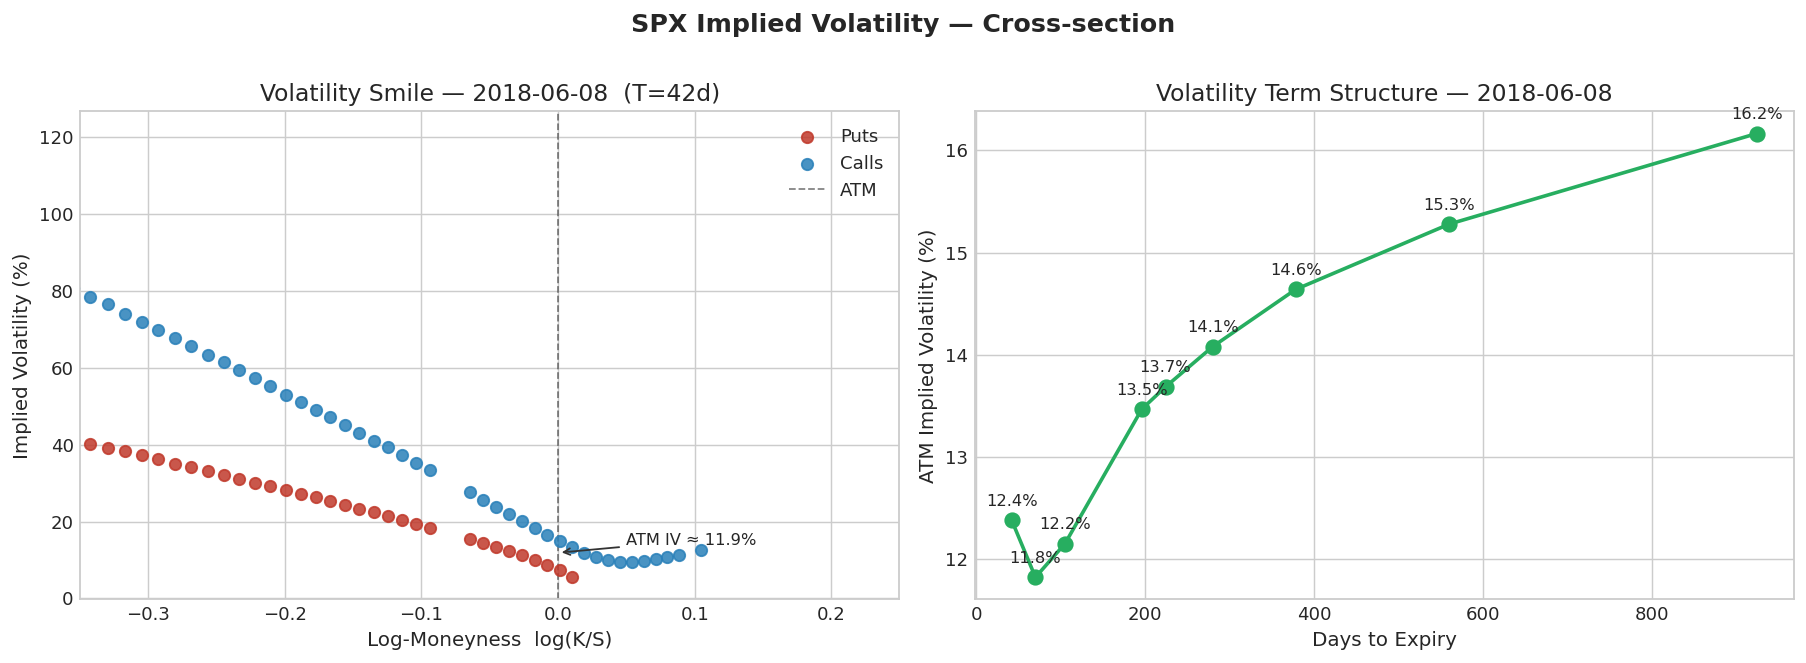

In [7]:
# ── Pick one representative date ──────────────────────────────────────────────
sample_date = pd.Timestamp('2018-06-08')   # change as needed
day_df = df[df['date'] == sample_date]

# Best expiry ~ TARGET_TENOR days
exp_options = day_df['exp_date'].unique()
best_exp    = exp_options[
    np.argmin(np.abs((pd.to_datetime(exp_options) - sample_date).days - TARGET_TENOR))
]
smile_df = day_df[day_df['exp_date'] == best_exp].sort_values('log_m')
T_actual = int((best_exp - sample_date).days)
print(f"Plotting smile for {sample_date.date()}  expiry={best_exp.date()}  T={T_actual}d")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Smile
ax = axes[0]
for opt_type, color, label in [('P','#c0392b','Puts'), ('C','#2980b9','Calls')]:
    sub = smile_df[smile_df['type'] == opt_type]
    ax.scatter(sub['log_m'], sub['iv']*100, color=color, s=40, alpha=0.85,
               label=label, zorder=3)
ax.axvline(0, color='#333', lw=1, ls='--', alpha=0.6, label='ATM')
atm_iv_val = smile_df[smile_df['log_m'].abs() < 0.01]['iv'].mean() * 100
ax.annotate(f'ATM IV ≈ {atm_iv_val:.1f}%', xy=(0, atm_iv_val),
            xytext=(0.05, atm_iv_val + 2), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#333', lw=1))
ax.set(xlabel='Log-Moneyness  log(K/S)', ylabel='Implied Volatility (%)',
       title=f'Volatility Smile — {sample_date.date()}  (T={T_actual}d)',
       xlim=(-0.35, 0.25))
ax.legend(fontsize=10)

# Right: Term structure of ATM IV
ts_rows = []
for exp in sorted(day_df['exp_date'].unique()):
    sub = day_df[(day_df['exp_date'] == exp) & (day_df['log_m'].abs() < 0.03)]
    if len(sub) > 0:
        ts_rows.append({'days': (exp - sample_date).days, 'atm_iv': sub['iv'].mean()*100})
ts = pd.DataFrame(ts_rows)
ax = axes[1]
ax.plot(ts['days'], ts['atm_iv'], 'o-', color='#27ae60', lw=2, ms=8)
for _, r in ts.iterrows():
    ax.annotate(f"{r['atm_iv']:.1f}%", (r['days'], r['atm_iv']),
                textcoords='offset points', xytext=(0, 8), fontsize=9, ha='center')
ax.set(xlabel='Days to Expiry', ylabel='ATM Implied Volatility (%)',
       title=f'Volatility Term Structure — {sample_date.date()}')

plt.suptitle('SPX Implied Volatility — Cross-section', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_smile_termstructure.png', dpi=150, bbox_inches='tight')
plt.show()


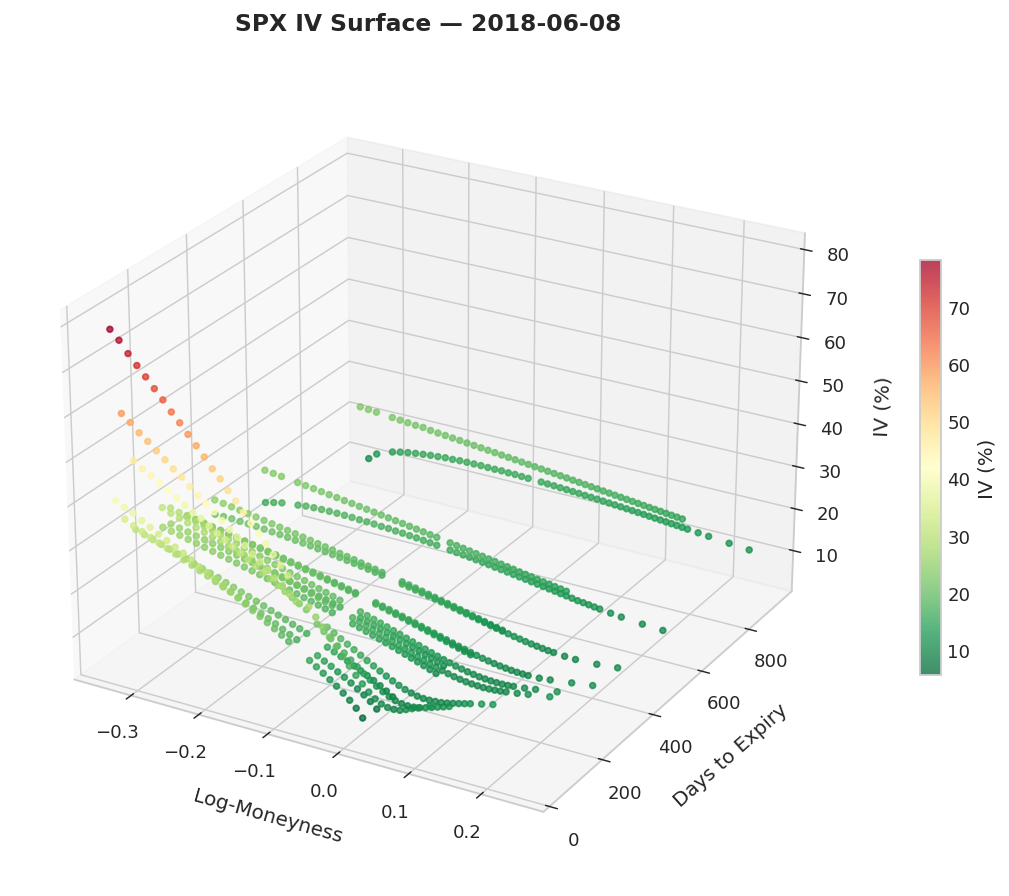

In [8]:
# ── 3-D volatility surface ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')
surf_df = day_df[(day_df['log_m'] > -0.35) & (day_df['log_m'] < 0.25)]
sc = ax.scatter(surf_df['log_m'], surf_df['T']*365, surf_df['iv']*100,
                c=surf_df['iv']*100, cmap='RdYlGn_r', s=10, alpha=0.75)
ax.set_xlabel('Log-Moneyness', labelpad=8)
ax.set_ylabel('Days to Expiry', labelpad=8)
ax.set_zlabel('IV (%)', labelpad=8)
ax.set_title(f'SPX IV Surface — {sample_date.date()}', fontweight='bold', pad=12)
plt.colorbar(sc, ax=ax, shrink=0.5, label='IV (%)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.savefig('fig2_vol_surface.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Daily time-series: ATM IV (constant maturity), skew, convexity

### 5.1 The varying-tenor problem

A naive approach would select, each day, the expiry closest to the target tenor (30 days). This produces a **heterogeneous** $X_t$: the selected option may have 42 days to expiry one day and 20 days the next, with discrete jumps each time a new expiry becomes the nearest. Within a single expiry cycle the tenor drifts continuously downward, then jumps abruptly at each roll. Comparing a 42-day IV one day to a 20-day IV the next breaks the consistency of the regressor series $X_t$.



### 5.2 Solution: constant-maturity interpolation

We bracket the target tenor $\tau = 30$ days between the two available expiries $T_1 \leq \tau < T_2$ and interpolate **in variance** (linearly in $\sigma^2$, not in $\sigma$):

$$\sigma_{\tau}^2 = \frac{T_2 - \tau}{T_2 - T_1}\,\sigma_{T_1}^2 + \frac{\tau - T_1}{T_2 - T_1}\,\sigma_{T_2}^2$$

$$\sigma_{\tau} = \sqrt{\sigma_{\tau}^2}$$

Interpolation is performed in variance rather than volatility because variance is additive in time under Black-Scholes: $\sigma^2 T$ represents the expected integrated variance, and it is this quantity that scales linearly with $T$. This is exactly the methodology used by the **CBOE to compute the VIX**.

### 5.3 Extracted metrics

The same three metrics are computed for each of the two bracketing expiries and then interpolated separately:

$$\text{Skew}_t = \overline{\text{IV}}_{\text{put wing}} - \overline{\text{IV}}_{\text{call wing}}$$

$$\text{Convexity}_t = \frac{\overline{\text{IV}}_{\text{put wing}} + \overline{\text{IV}}_{\text{call wing}}}{2} - \text{ATM\_IV}_t$$

In [9]:
metrics = extract_daily_metrics(df, TARGET_TENOR, WING_LOW, WING_HIGH_PUT, WING_LOW_CALL, WING_HIGH)
metrics.head()

✓ Daily metrics: 253 trading days  (constant-maturity 30d interpolation)


,atm_iv,skew,convexity,iv_put_wing,iv_call_wing
date,,,,,
2017-06-08,0.146731,NaN,NaN,0.222966,NaN
2017-06-09,0.137690,NaN,NaN,0.180820,NaN
2017-06-12,0.071861,0.087259,0.072939,0.188429,0.101170
2017-06-13,0.124111,0.081604,0.017452,0.182365,0.100762
2017-06-14,0.073378,0.072546,0.072494,0.182145,0.109599


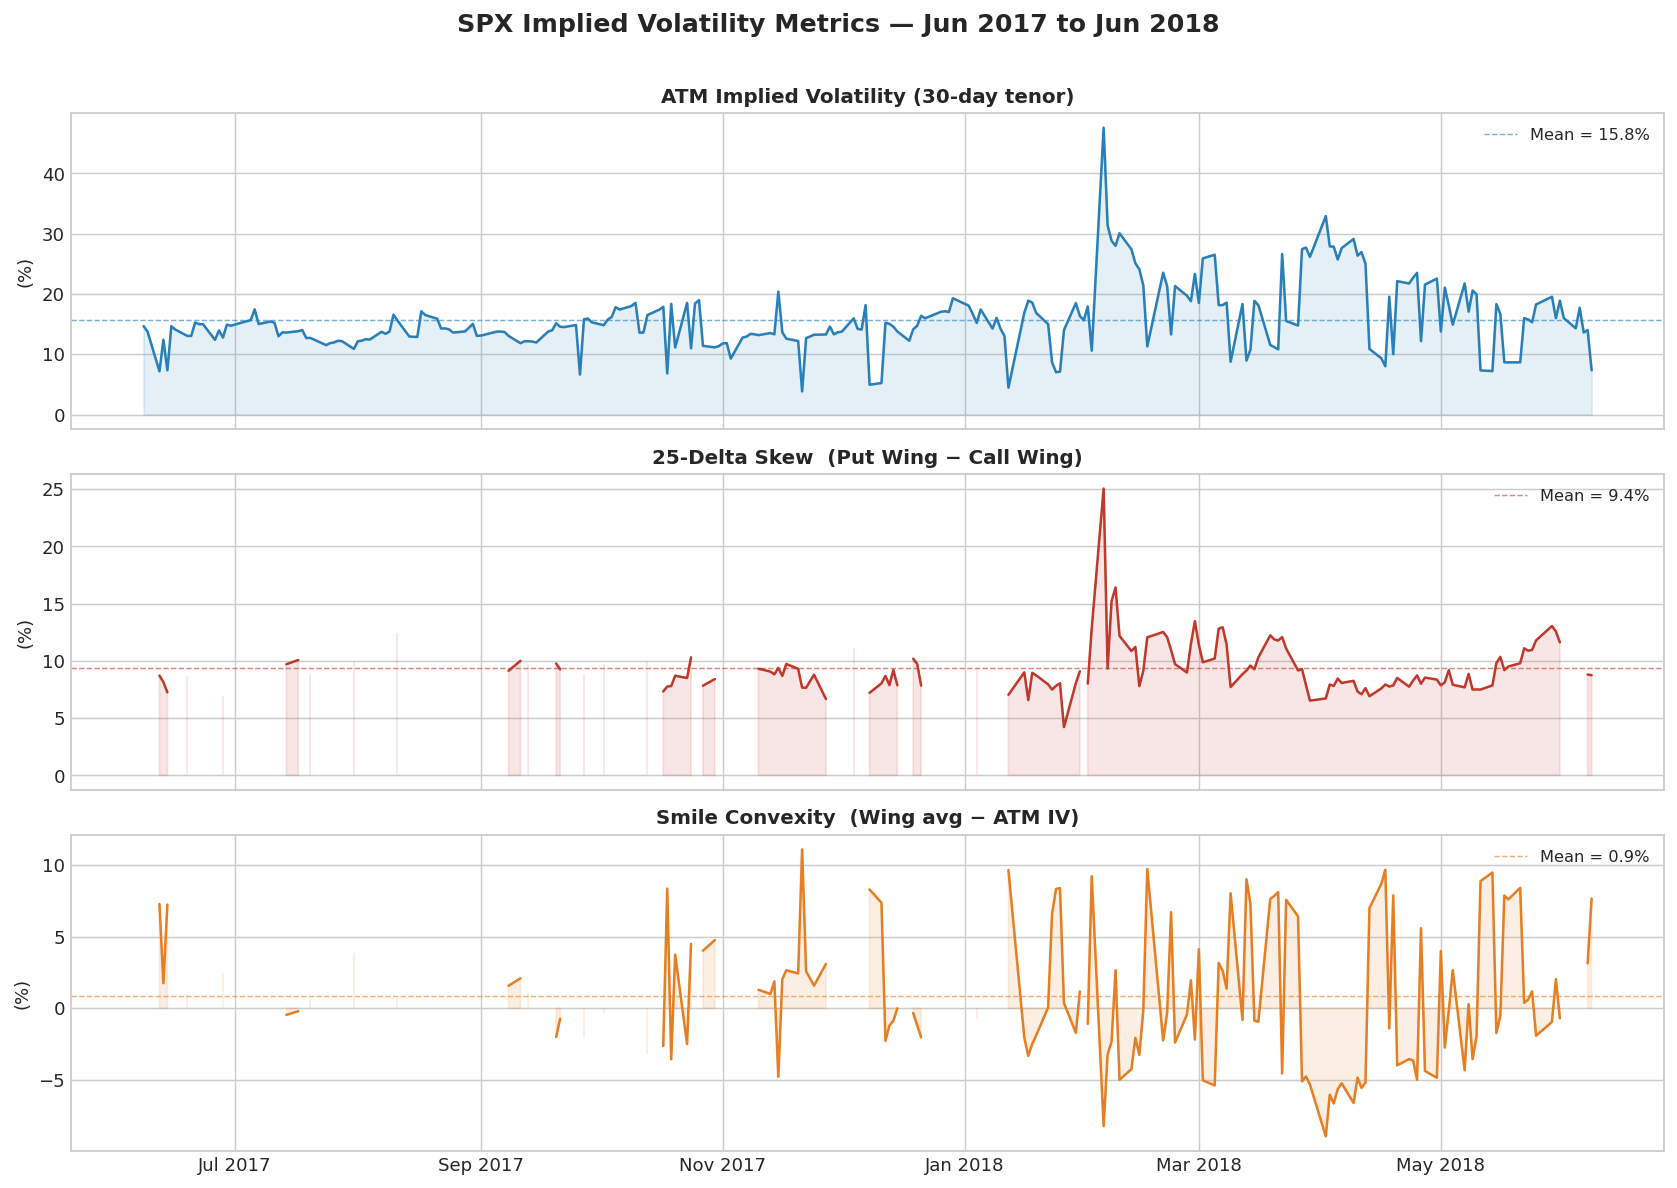

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = ['#2980b9', '#c0392b', '#e67e22']
titles = ['ATM Implied Volatility (30-day tenor)',
          '25-Delta Skew  (Put Wing − Call Wing)',
          'Smile Convexity  (Wing avg − ATM IV)']
cols   = ['atm_iv', 'skew', 'convexity']

for ax, col, color, title in zip(axes, cols, colors, titles):
    y = metrics[col] * 100
    ax.plot(metrics.index, y, color=color, lw=1.4)
    ax.fill_between(metrics.index, y, alpha=0.12, color=color)
    ax.axhline(y.mean(), color=color, lw=0.8, ls='--', alpha=0.6,
               label=f'Mean = {y.mean():.1f}%')
    ax.set_ylabel('(%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('SPX Implied Volatility Metrics — Jun 2017 to Jun 2018',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_iv_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Realized volatility & Variance Risk Premium

**Realized volatility** (historical) over a rolling 21-day window:

$$RV_t = \sqrt{252} \cdot \hat\sigma\left(r_{t-20},\ldots,r_{t}\right), \quad r_t = \ln\frac{S_t}{S_{t-1}}$$

**Forward realized volatility** (what we want to predict):

$$RV^{\text{fwd}}_t = \sqrt{252} \cdot \hat\sigma\left(r_{t+1},\ldots,r_{t+21}\right)$$

**Variance Risk Premium**:

$$\text{VRP}_t = IV_t - RV_t \quad (\text{typically positive → investors overpay for vol protection})$$


=== Variance Risk Premium ===
Mean VRP (IV − RV) : +5.05%
Std  VRP           :  6.56%
% positive (IV>RV) :  81.5%
Sample size        :  211 days


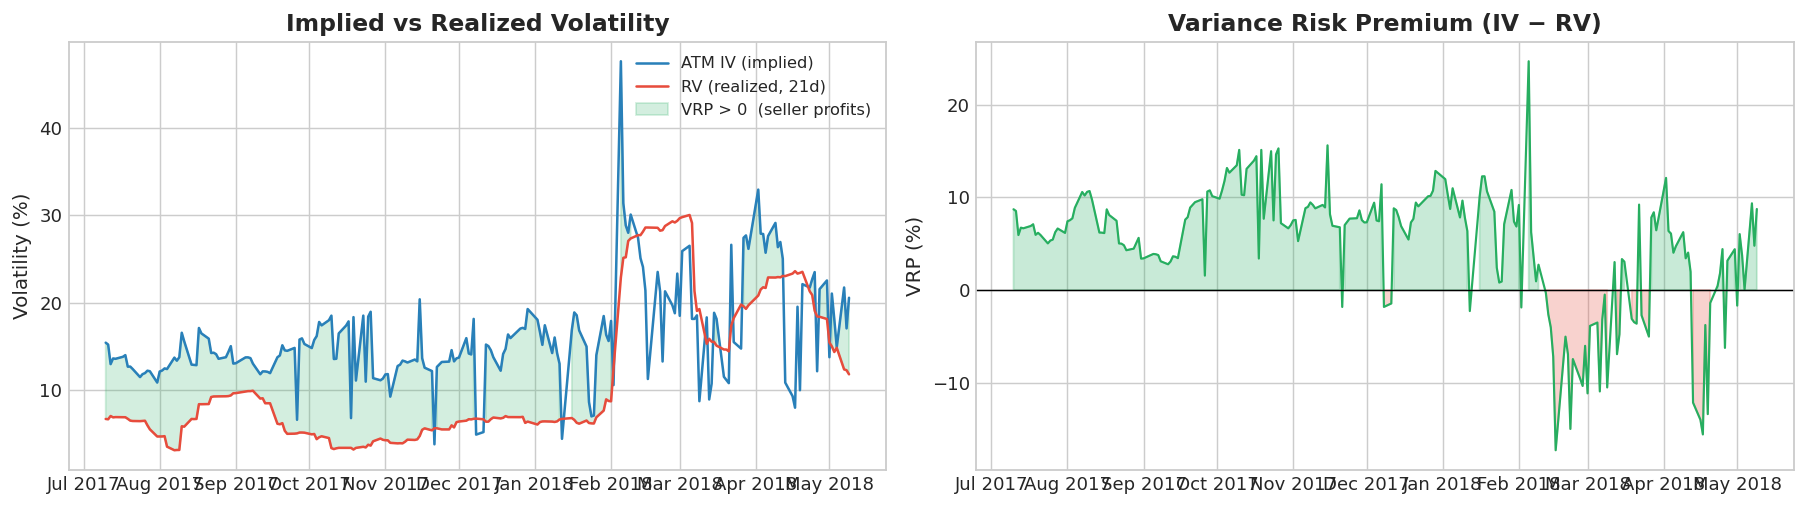

In [11]:
# ── Spot price from the dataset itself (put-call parity median per day) ────────
spot_ts = df.groupby('date')['spot'].median().sort_index()

# Add extra buffer around the sample for the rolling windows
log_ret = np.log(spot_ts / spot_ts.shift(1))

rv_past    = log_ret.rolling(RV_WINDOW).std() * np.sqrt(252)
rv_forward = log_ret.shift(-RV_WINDOW).rolling(RV_WINDOW).std() * np.sqrt(252)

# Merge into regression dataframe
reg = metrics.copy()
reg['rv_past']    = rv_past.reindex(reg.index)
reg['rv_forward'] = rv_forward.reindex(reg.index)
reg['vrp']        = reg['atm_iv'] - reg['rv_past']
reg = reg.dropna(subset=['atm_iv', 'rv_past', 'rv_forward'])

print("=== Variance Risk Premium ===")
print(f"Mean VRP (IV − RV) : {reg['vrp'].mean()*100:+.2f}%")
print(f"Std  VRP           :  {reg['vrp'].std()*100:.2f}%")
print(f"% positive (IV>RV) :  {(reg['vrp']>0).mean()*100:.1f}%")
print(f"Sample size        :  {len(reg)} days")

# ── Plot IV vs RV ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(reg.index, reg['atm_iv']*100, color='#2980b9', lw=1.4, label='ATM IV (implied)')
ax.plot(reg.index, reg['rv_past']*100, color='#e74c3c', lw=1.4, label='RV (realized, 21d)')
ax.fill_between(reg.index, reg['atm_iv']*100, reg['rv_past']*100,
                where=reg['atm_iv'] > reg['rv_past'], alpha=0.2, color='#27ae60',
                label='VRP > 0  (seller profits)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('Volatility (%)')
ax.set_title('Implied vs Realized Volatility', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(reg.index, reg['vrp']*100, color='#27ae60', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']>0, alpha=0.25, color='#27ae60')
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']<=0, alpha=0.25, color='#e74c3c')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('VRP (%)')
ax.set_title('Variance Risk Premium (IV − RV)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_vrp.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Regression analysis

We implement OLS from scratch (as expected in an econometrics course):

$$\hat\beta = (X'X)^{-1}X'y, \qquad \widehat{\text{Var}}(\hat\beta) = s^2 (X'X)^{-1}, \qquad s^2 = \frac{\hat\varepsilon'\hat\varepsilon}{n-k}$$


In [12]:
y = reg['rv_forward']

### Model 1 — Mincer-Zarnowitz regression (baseline)

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \varepsilon_t$$

**Interpretation**:
- If $\alpha = 0$ and $\beta_1 = 1$: IV is an **unbiased predictor** of future RV
- In practice: $\beta_1 < 1$ and $\alpha > 0$ → IV **over-estimates** RV on average (= VRP)

In [13]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0679    0.0157    4.320    0.0000 ***
ATM_IV                    0.2929    0.0918    3.189    0.0016 **
──────────────────────────────────────────────────────────────
R²                        0.0464
Adj. R²                   0.0418
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 2 — Adding skew

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \varepsilon_t$$


In [14]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0822    0.0307    2.677    0.0085 **
ATM_IV                    0.1023    0.1099    0.930    0.3541 
Skew                      0.4513    0.3295    1.369    0.1734 
──────────────────────────────────────────────────────────────
R²                        0.0337
Adj. R²                   0.0176
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 3 — Full model

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \beta_3 \cdot \text{Convexity}_t + \varepsilon_t$$

In [15]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0029    0.0335    0.086    0.9313 
ATM_IV                    0.9838    0.2209    4.453    0.0000 ***
Skew                     -0.4165    0.3617   -1.152    0.2517 
Convexity                 1.3739    0.3054    4.499    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1742
Adj. R²                   0.1533
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 4

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Convexity}_t + \varepsilon_t$$

In [16]:
print("\n" + "═"*62)
print("MODEL 4 — RV_fwd ~ ATM_IV + Convexity")
print("═"*62)
r4 = ols(y, reg[['atm_iv', 'convexity']])
reg_table(r4, ['Const', 'ATM_IV', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 4 — RV_fwd ~ ATM_IV + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                    -0.0079    0.0322   -0.245    0.8068 
ATM_IV                    0.8279    0.1748    4.735    0.0000 ***
Convexity                 1.1863    0.2587    4.586    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1650
Adj. R²                   0.1510
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [17]:
data  = reg[['atm_iv', 'convexity', 'rv_forward']].dropna()
y_m4  = data['rv_forward'].values
X_m4  = sm.add_constant(data[['atm_iv', 'convexity']].values)

res_ols = sm.OLS(y_m4, X_m4).fit()
resid = res_ols.resid

jb_stat,    jb_p          = stats.jarque_bera(resid)
dw                         = durbin_watson(resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_ols, nlags=21)
white_stat, white_p, _, _ = het_white(resid, X_m4)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

Jarque-Bera     : stat=24.645  p=0.0000  reject normality
Durbin-Watson   : 0.2112            autocorrelation present
White           : stat=10.263  p=0.0681  cannot reject homoscedasticity
Breusch-Godfrey : stat=108.628  p=  0.0000  reject no autocorrelation


we introduce Newey and West robust standard error

In [18]:
res_nw  = sm.OLS(y_m4, X_m4).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

# Vérification : les coefs doivent être identiques à r4
print("Coefs statsmodels :", res_ols.params)
print("Coefs from scratch:", r4['beta'])
print()
print(res_nw.summary())

Coefs statsmodels : [-0.0078956   0.82791227  1.18628464]
Coefs from scratch: [-0.0078956   0.82791227  1.18628464]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     6.596
Date:                Sun, 17 May 2026   Prob (F-statistic):            0.00192
Time:                        16:25:20   Log-Likelihood:                 147.84
No. Observations:                 123   AIC:                            -289.7
Df Residuals:                     120   BIC:                            -281.2
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------

### Models with VIX

In [19]:
# Import VIc index from yahoofinance 

vix = yf.Ticker("^VIX")
hist = vix.history(start="2017-06-09", end = "2018-06-08")
Vix_close = hist["Close"]

In [20]:
Vix_close.index = Vix_close.index.tz_localize(None)
reg = reg.join(Vix_close.rename("vix"), how="left")
reg

,atm_iv,skew,convexity,iv_put_wing,iv_call_wing,rv_past,rv_forward,vrp,vix
date,,,,,,,,,
2017-07-10,0.154434,NaN,NaN,0.181322,NaN,0.067296,0.031866,0.087139,11.11
2017-07-11,0.152247,NaN,NaN,0.193709,NaN,0.066963,0.031895,0.085284,10.89
2017-07-12,0.129961,NaN,NaN,0.188007,NaN,0.070671,0.058953,0.059289,10.30
2017-07-13,0.136401,NaN,NaN,0.190928,NaN,0.069139,0.058500,0.067262,9.90
2017-07-14,0.136024,0.097145,-0.004639,0.179957,0.082813,0.069434,0.067324,0.066589,9.51
...,...,...,...,...,...,...,...,...,...
2018-05-03,0.181136,0.092004,-0.001848,0.225290,0.133286,0.143787,0.100371,0.037349,15.90
2018-05-04,0.149148,0.079209,0.026659,0.215411,0.136202,0.148595,0.093206,0.000552,14.77
2018-05-07,0.217460,0.076918,-0.043449,0.212470,0.135552,0.123920,0.095326,0.093540,14.75


In [21]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv', "vix"]])
reg_table(r1, ['Const', 'ATM_IV', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0363    0.0151    2.408    0.0169 *
ATM_IV                   -0.3043    0.1228   -2.479    0.0140 *
VIX                       0.0095    0.0014    6.644    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.2134
Adj. R²                   0.2058
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [22]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew' , "vix"]])
reg_table(r2, ['Const', 'ATM_IV', 'Skew', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0845    0.0287    2.947    0.0039 **
ATM_IV                   -0.3339    0.1440   -2.318    0.0221 *
Skew                     -0.2151    0.3443   -0.625    0.5333 
VIX                       0.0088    0.0020    4.316    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1645
Adj. R²                   0.1435
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [23]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity', "vix"]])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0250    0.0544    0.459    0.6468 
ATM_IV                    0.6130    0.7514    0.816    0.4162 
Skew                     -0.3849    0.3679   -1.046    0.2977 
Convexity                 1.0028    0.7811    1.284    0.2017 
VIX                       0.0027    0.0052    0.516    0.6065 
──────────────────────────────────────────────────────────────
R²                        0.1760
Adj. R²                   0.1481
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [24]:
print("\n" + "═"*62)
print("MODEL 4 — RV_fwd ~ ATM_IV + Convexity")
print("═"*62)
r4 = ols(y, reg[['atm_iv', 'convexity', "vix"]])
reg_table(r4, ['Const', 'ATM_IV', 'Convexity', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 4 — RV_fwd ~ ATM_IV + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0228    0.0544    0.419    0.6763 
ATM_IV                    0.3479    0.7076    0.492    0.6239 
Convexity                 0.7091    0.7292    0.973    0.3328 
VIX                       0.0036    0.0051    0.700    0.4852 
──────────────────────────────────────────────────────────────
R²                        0.1684
Adj. R²                   0.1474
N                            123
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [25]:
data  = reg[['atm_iv', 'convexity', 'rv_forward' , "vix"]].dropna()
y_m4  = data['rv_forward'].values
X_m4  = sm.add_constant(data[['atm_iv', 'convexity', "vix"]].values)

res_ols = sm.OLS(y_m4, X_m4).fit()
resid = res_ols.resid

jb_stat,    jb_p          = stats.jarque_bera(resid)
dw                         = durbin_watson(resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_ols, nlags=21)
white_stat, white_p, _, _ = het_white(resid, X_m4)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

Jarque-Bera     : stat=27.180  p=0.0000  reject normality
Durbin-Watson   : 0.1939            autocorrelation present
White           : stat=11.934  p=0.2171  cannot reject homoscedasticity
Breusch-Godfrey : stat=109.827  p=  0.0000  reject no autocorrelation


In [26]:
res_nw  = sm.OLS(y_m4, X_m4).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

# Vérification : les coefs doivent être identiques à r4
print("Coefs statsmodels :", res_ols.params)
print("Coefs from scratch:", r4['beta'])
print()
print(res_nw.summary())

Coefs statsmodels : [0.02277584 0.34787964 0.70910702 0.00356729]
Coefs from scratch: [0.02277584 0.34787964 0.70910702 0.00356729]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     5.252
Date:                Sun, 17 May 2026   Prob (F-statistic):            0.00194
Time:                        16:25:21   Log-Likelihood:                 148.09
No. Observations:                 123   AIC:                            -288.2
Df Residuals:                     119   BIC:                            -276.9
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975

## 9 · Fixed Effects & Random Effects — IV Surface Panel

### 9.1 Motivation

The IV surface contains **22 individual expiries** observed daily. A naive pooled OLS
treats all expiries identically, but options of different maturities have systematically
different IV levels due to the **term structure**: long-dated options are structurally
more expensive than short-dated ones.

Ignoring this heterogeneity biases the OLS coefficients: part of β(ATM_IV) would capture
the term structure effect rather than the true predictive relationship.

We verify this with an **F-test on entity fixed effects**:

$$F = \frac{(SSR_{\text{pooled}} - SSR_{\text{FE}}) / (N-1)}{SSR_{\text{FE}} / (NT - N - K)} \sim F(N-1,\ NT-N-K)$$

A significant F-statistic confirms that expiry-level heterogeneity exists and must be controlled.

### 9.2 Fixed Effects — within estimator

$$RV^{\text{fwd}}_{t} = \alpha_i + \beta_1\, IV_{it} + \beta_2\, \text{Conv}_{it} + \varepsilon_{it}$$

$\alpha_i$ absorbs all time-invariant characteristics of each expiry (its average IV level).
Identification comes exclusively from **within-expiry deviations over time**:

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \quad \tilde{x}_{it} = x_{it} - \bar{x}_i$$

Then OLS on the demeaned variables. The constant and all between-expiry information are removed.

### 9.3 Random Effects — GLS via quasi-demeaning

Assumes $\alpha_i \sim \mathcal{N}(0,\, \sigma^2_\alpha)$ **uncorrelated with regressors**.
Uses partial demeaning with parameter $\theta \in [0, 1]$:

$$\theta = 1 - \sqrt{\frac{\sigma^2_\varepsilon}{\sigma^2_\varepsilon + T \cdot \sigma^2_\alpha}}, \qquad \tilde{y}_{it} = y_{it} - \theta\,\bar{y}_i$$

More efficient than FE if the assumption holds, as it exploits both **within** and **between** variation.


In [27]:
def within_estimator(panel, y_col, x_cols, entity_col):
    # demean then OLS on demeaned data
    p = panel.copy()
    
    # Compute entity means
    for col in [y_col] + x_cols:
        p[col + '_mean'] = p.groupby(entity_col)[col].transform('mean')
    
    # Demean
    p[y_col + '_dm'] = p[y_col] - p[y_col + '_mean']
    for col in x_cols:
        p[col + '_dm']  = p[col]  - p[col  + '_mean']
    
    # OLS on demeaned variables (no constant — absorbed by demeaning)
    y_dm = p[y_col + '_dm'].values
    X_dm = p[[col + '_dm' for col in x_cols]].values
    
    result = ols(y_dm, X_dm, add_const=False)
    return result

In [28]:
# ── Panel par expiry individuelle ──────────────────────────────────────────────
def build_surface_panel(df, reg):
    rows = []
    for (date, exp), g in df.groupby(['date', 'exp_date']):
        T_days = (exp - date).days
        if T_days < 7:
            continue
        atm_iv = g[g['log_m'].abs() < 0.03]['iv'].mean()
        p_wing = g[(g['log_m'] > WING_LOW)  & (g['log_m'] < WING_HIGH_PUT) & (g['type']=='P')]['iv'].mean()
        c_wing = g[(g['log_m'] > WING_LOW_CALL) & (g['log_m'] < WING_HIGH)  & (g['type']=='C')]['iv'].mean()
        conv   = (p_wing + c_wing)/2 - atm_iv if not (np.isnan(p_wing) or np.isnan(c_wing)) else np.nan
        if np.isnan(atm_iv):
            continue
        rows.append({'date': date, 'expiry': exp,
                     'T_days': T_days, 'atm_iv': atm_iv, 'convexity': conv})

    panel = (pd.DataFrame(rows)
               .merge(reg[['rv_forward']].reset_index(), on='date', how='left')
               .dropna(subset=['rv_forward', 'atm_iv']))
    return panel

panel_surf = build_surface_panel(df, reg)
print(f"Panel surface : {len(panel_surf)} obs")
print(f"  Dates    : {panel_surf['date'].nunique()}")
print(f"  Expiries : {panel_surf['expiry'].nunique()}")

# ── Pooled OLS (référence) ─────────────────────────────────────────────────────
x_cols   = ['atm_iv', 'convexity']
r_pooled = ols(panel_surf['rv_forward'].values,
               panel_surf[x_cols].values)

# ── Fixed Effects par expiry ───────────────────────────────────────────────────
fe_surf = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')

# ── F-test : effets fixes significatifs ? ─────────────────────────────────────
N  = panel_surf['expiry'].nunique()
NT = len(panel_surf)
K  = len(x_cols)
SSR_pool = np.sum(r_pooled['resid']**2)
SSR_fe   = np.sum(fe_surf['resid']**2)
F_stat   = ((SSR_pool - SSR_fe) / (N - 1)) / (SSR_fe / (NT - N - K))
F_p      = 1 - stats.f.cdf(F_stat, N - 1, NT - N - K)

# ── Random Effects + Hausman via linearmodels ──────────────────────────────────
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

panel_idx = panel_surf.set_index(['expiry', 'date'])
y = panel_idx['rv_forward']
X = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y, X[x_cols], entity_effects=True).fit(
            cov_type='clustered', cluster_entity=True)
re_lm = RandomEffects(y, X).fit()

# ── Résultats ──────────────────────────────────────────────────────────────────
print('\n' + '═'*62)
print('POOLED OLS vs FIXED EFFECTS — surface complète (22 expiries)')
print('═'*62)
print(f"{'':22} {'Pooled OLS':>12} {'Fixed Effects':>14}")
print('─'*50)
print(f"{'β(ATM_IV)':22} {r_pooled['beta'][1]:>12.4f} {fe_surf['beta'][0]:>14.4f}")
print(f"{'β(Convexity)':22} {r_pooled['beta'][2]:>12.4f} {fe_surf['beta'][1]:>14.4f}")
print(f"{'R²':22} {r_pooled['r2']:>12.4f} {fe_surf['r2']:>14.4f}")
print('─'*50)
print(f"\nF-test effets fixes : F = {F_stat:.3f},  p = {F_p:.4f}  df = ({N-1}, {NT-N-K})")
print(f"→ {'Effets fixes significatifs → terme structure confirmée' if F_p < 0.05 else 'Non significatif'}")

print('\n' + '═'*62)
print('FIXED EFFECTS (linearmodels, SE clustered par expiry)')
print('═'*62)
print(fe_lm.summary.tables[1])

print('\n' + '═'*62)
print('RANDOM EFFECTS')
print('═'*62)
print(re_lm.summary.tables[1])

print('\n' + '═'*62)
print('HAUSMAN TEST')
print('═'*62)
from linearmodels.panel import compare
print(compare({'FE': fe_lm, 'RE': re_lm}))

Panel surface : 2259 obs
  Dates    : 211
  Expiries : 21

══════════════════════════════════════════════════════════════
POOLED OLS vs FIXED EFFECTS — surface complète (22 expiries)
══════════════════════════════════════════════════════════════
                         Pooled OLS  Fixed Effects
──────────────────────────────────────────────────
β(ATM_IV)                    1.1635         0.6768
β(Convexity)                 1.1168         1.7703
R²                           0.1471         0.0600
──────────────────────────────────────────────────

F-test effets fixes : F = 14.377,  p = 0.0000  df = (20, 2236)
→ Effets fixes significatifs → terme structure confirmée

══════════════════════════════════════════════════════════════
FIXED EFFECTS (linearmodels, SE clustered par expiry)
══════════════════════════════════════════════════════════════
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI 

### 9.4 Hausman test — choosing between FE and RE

$$H_0: \alpha_i \perp X_{it} \quad \Rightarrow \text{RE consistent and efficient}$$

$$H = (\hat\beta_{FE} - \hat\beta_{RE})^\top\,[\text{Var}(\hat\beta_{FE}) - \text{Var}(\hat\beta_{RE})]^{-1}\,(\hat\beta_{FE} - \hat\beta_{RE}) \sim \chi^2(K)$$

- **Reject** $H_0$: expiry effects correlated with regressors → only **FE** is consistent
- **Cannot reject**: RE is consistent and more efficient → **prefer RE**

In [29]:
fe_lm = PanelOLS(y, X[x_cols], entity_effects=True).fit()   # sans clustering
re_lm = RandomEffects(y, X).fit()

b_fe   = fe_lm.params.values
b_re   = re_lm.params[['atm_iv', 'convexity']].values
V_fe   = fe_lm.cov.values
V_re   = re_lm.cov.loc[['atm_iv', 'convexity'], ['atm_iv', 'convexity']].values
diff   = b_fe - b_re
H      = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p      = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f"Hausman : stat={H:.4f}  p={p:.4f}")

Hausman : stat=75.7131  p=0.0000


# ARMA
(for a single TS -> atm_iv)

In [30]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -4.0529
p-value: 0.0012


p>0.05 -> non stationnary

In [31]:
# first difference is stationary (first diff is daily change in implied vol)
atm_iv_diff = reg['atm_iv'].dropna().diff().dropna()
result_diff = adfuller(atm_iv_diff)
print(f"ADF on first difference: stat={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

ADF on first difference: stat=-6.6011, p=0.0000


Best ARIMA order: (p=3, d=1, q=1) with AIC=-694.87


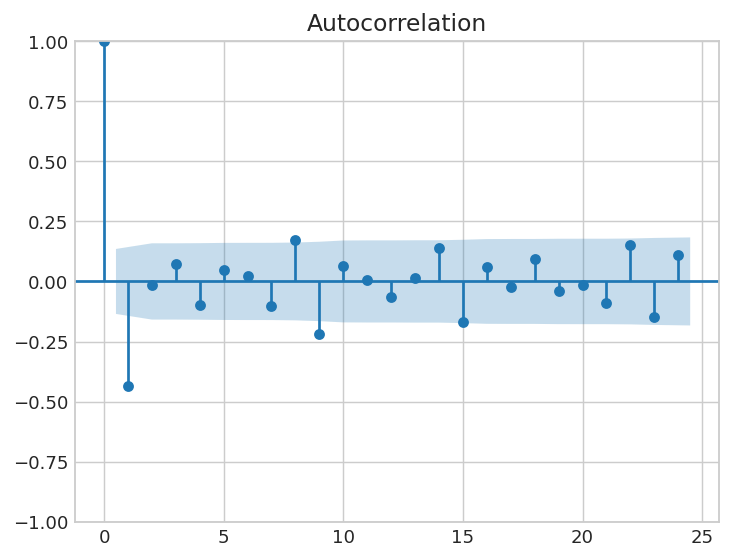

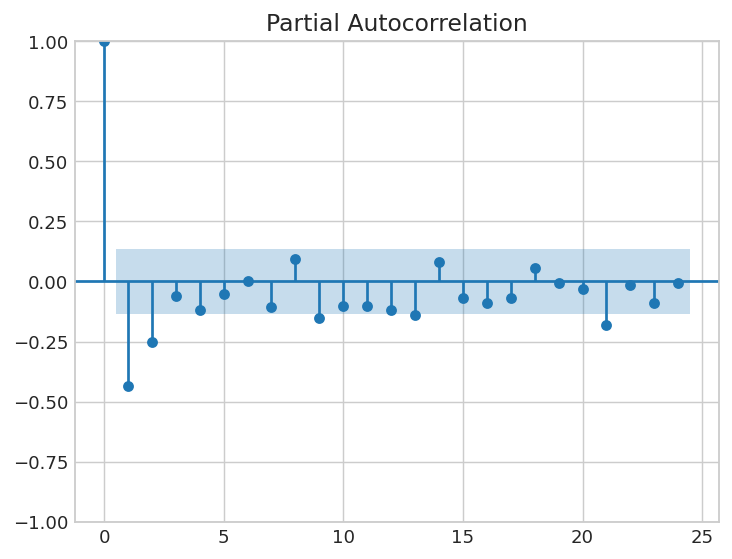

In [32]:
# identfy p and q

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(atm_iv_diff) # gives q
plot_pacf(atm_iv_diff) # gives p

from statsmodels.tsa.arima.model import ARIMA
import itertools

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model = ARIMA(reg['atm_iv'].dropna(), order=(p,1,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=1, q={best_q}) with AIC={best_aic:.2f}")

In [33]:
model = ARIMA(reg['atm_iv'].dropna(), order=(best_p,1,best_q)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                 atm_iv   No. Observations:                  211
Model:                 ARIMA(3, 1, 1)   Log Likelihood                 352.437
Date:                Sun, 17 May 2026   AIC                           -694.874
Time:                        16:25:24   BIC                           -678.139
Sample:                             0   HQIC                          -688.109
                                - 211                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3299      0.061      5.401      0.000       0.210       0.450
ar.L2          0.1834      0.077      2.396      0.017       0.033       0.333
ar.L3          0.1263      0.077      1.637      0.1

Kurtosis = 51.55 → extreme fat tails (normal distribution has kurtosis = 3)

JB huge -> residuals non gaussian

heteroskedasticity : we reject it, the variance is not constant

In [34]:
# ljung-box test : check that autocorr is low
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(model.resid, lags=10)

,lb_stat,lb_pvalue
1,0.002970,0.956537
2,0.020783,0.989662
3,0.030788,0.998576
4,0.258298,0.992345
5,0.540532,0.990564
6,0.643383,0.995632
7,1.576377,0.979547
8,2.108442,0.977506
9,11.190165,0.262899
10,11.616211,0.311563


p-value > 0.05, residuals are WN

Recap ARMA : for now just did with atm_iv, test with vix or skew or convexity ?

# VAR

with atm_iv, skew and convexity (and vix ?)

In [35]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -4.0529
p-value: 0.0012


In [36]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['skew'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.2484
p-value: 0.0173


In [37]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['convexity'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -8.6572
p-value: 0.0000


In [38]:
# correction of stationnarity for atm_iv, skew and convexity are already ok

atm_iv_diff = reg['atm_iv'].dropna().diff().dropna()
result_diff = adfuller(atm_iv_diff)
print(f"ADF on first difference: stat={result_diff[0]:.4f}, p={result_diff[1]:.4f}")

ADF on first difference: stat=-6.6011, p=0.0000


In [39]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'datm_iv'   : reg['atm_iv'].diff(),   # first difference
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity']         # ok stat
}).dropna()

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     16:25:24
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -21.1293
Nobs:                     121.000    HQIC:                  -21.4174
Log likelihood:           813.603    FPE:                4.10303e-10
AIC:                     -21.6145    Det(Omega_mle):     3.46602e-10
--------------------------------------------------------------------
Results for equation datm_iv
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.019187         0.025624            0.749           0.454
L1.datm_iv           0.070057         0.259384            0.270           0.787
L1.skew             -0.316090         0.334796           -0.94

every p-value > 0.05

In [40]:
# granger causality tests
print(results.test_causality('datm_iv', ['skew', 'convexity'], kind='f'))

# Does ATM_IV Granger-cause skew ?
print(results.test_causality('skew', ['datm_iv'], kind='f'))

# Does ATM_IV Granger-cause convexity ?
print(results.test_causality('convexity', ['datm_iv'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ['skew', 'convexity'] do not Granger-cause datm_iv: reject at 5% significance level. Test statistic: 6.201, critical value: 2.398>, p-value: 0.000>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: datm_iv does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 0.498, critical value: 3.022>, p-value: 0.608>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: datm_iv does not Granger-cause convexity: fail to reject at 5% significance level. Test statistic: 1.097, critical value: 3.022>, p-value: 0.335>


the 3 tests fail to reject H0 at 5%

no relationship between atm_iv, skew and convexity

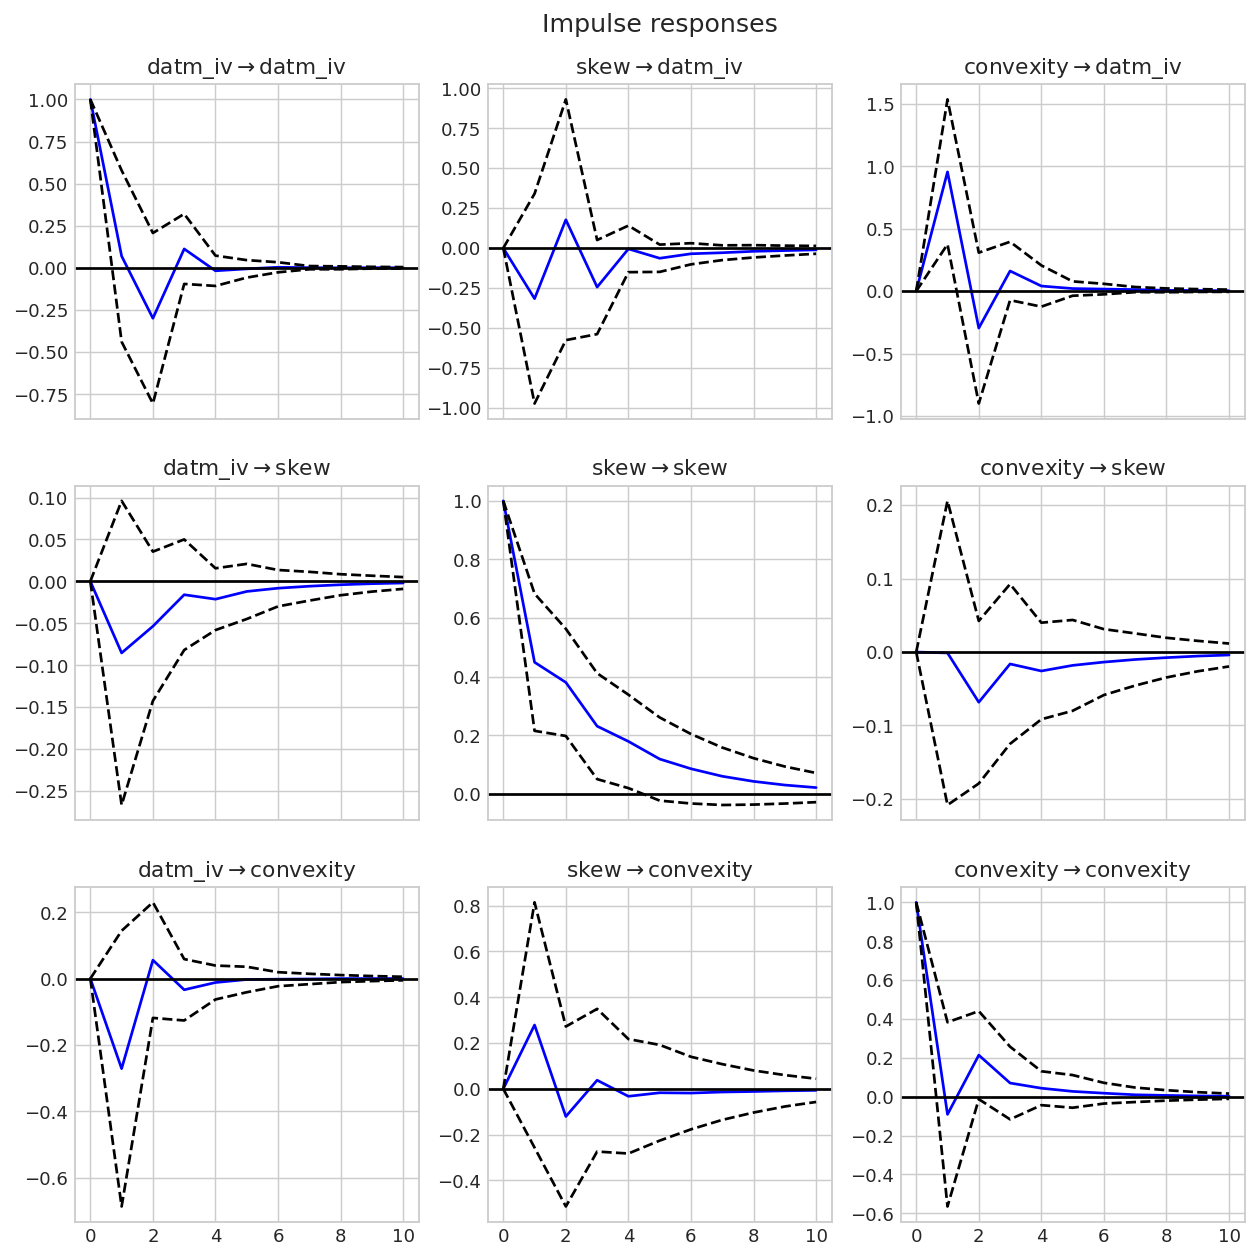

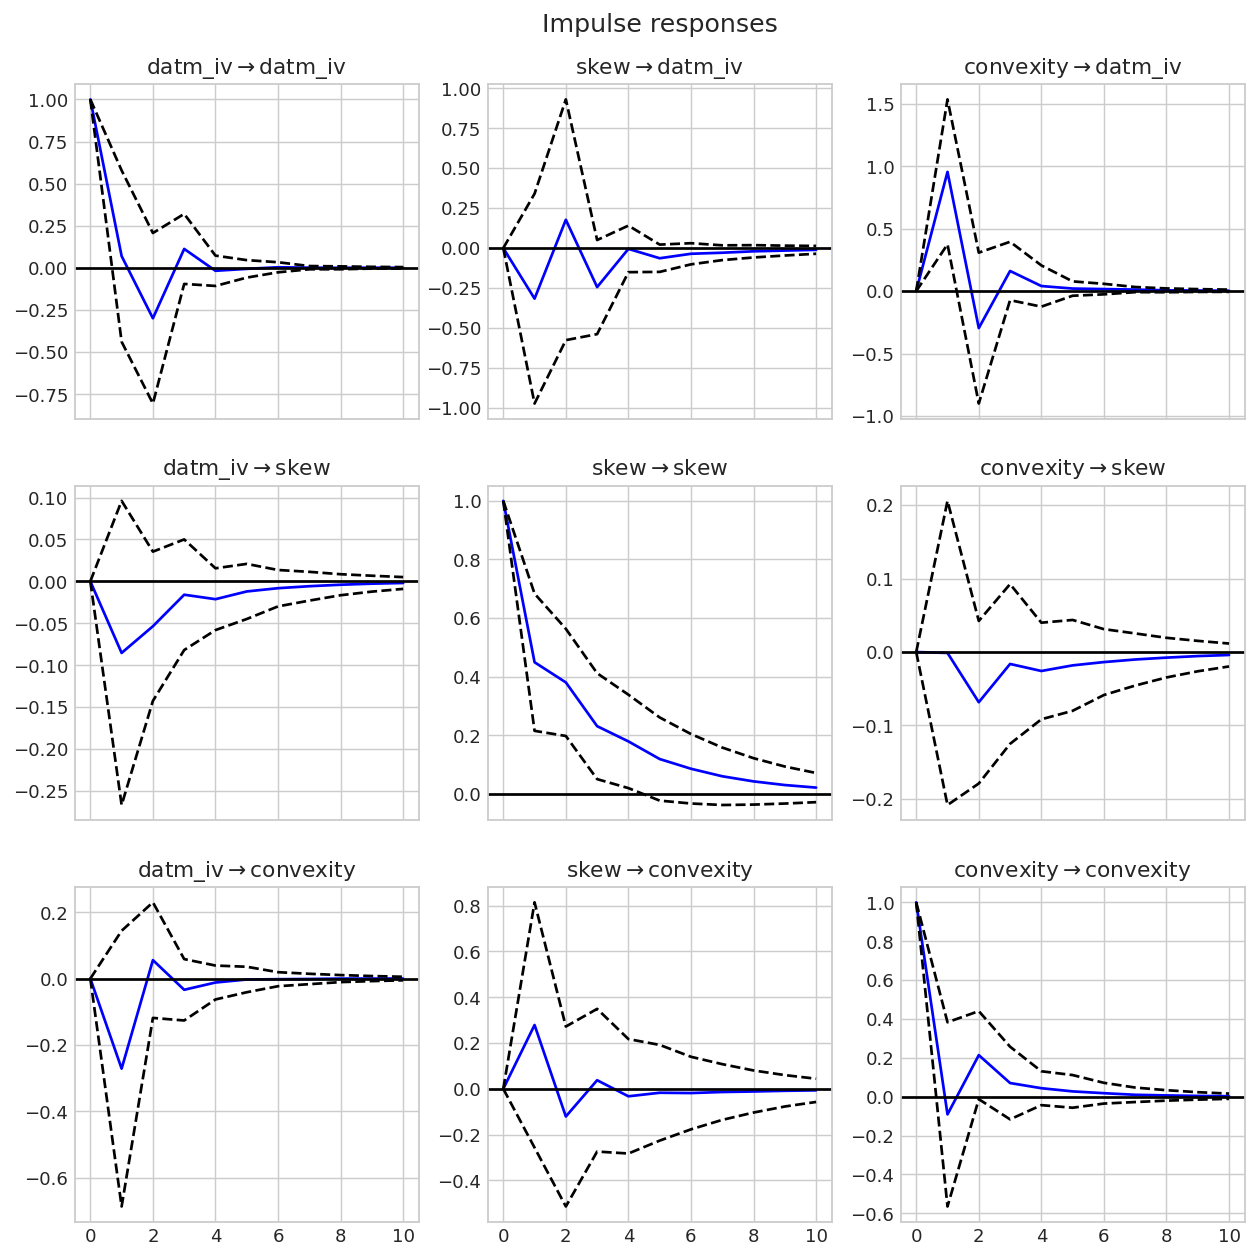

In [41]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)

black lines -> confidence interval

VAR with atm_iv, skew, convexity and SP500 daily returns

In [42]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(np.log(spot_ts / spot_ts.shift(1)).dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -6.4561
p-value: 0.0000


In [43]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'datm_iv'   : reg['atm_iv'].diff(),   # first difference
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity'],       # ok stat
    'ret'       : np.log(spot_ts / spot_ts.shift(1))         # ok stat
}).dropna()

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     16:25:25
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -30.4945
Nobs:                     121.000    HQIC:                  -30.9885
Log likelihood:           1244.48    FPE:                2.48670e-14
AIC:                     -31.3263    Det(Omega_mle):     1.86634e-14
--------------------------------------------------------------------
Results for equation datm_iv
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.024095         0.029254            0.824           0.410
L1.datm_iv          -0.023509         0.292117           -0.080           0.936
L1.skew             -0.407853         0.359832           -1.13

In [44]:
print(results.test_causality('skew', ['ret'], kind='f'))
print(results.test_causality('datm_iv', ['ret'], kind='f'))
print(results.test_causality('convexity', ['ret'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 2.146, critical value: 3.016>, p-value: 0.118>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause datm_iv: fail to reject at 5% significance level. Test statistic: 0.264, critical value: 3.016>, p-value: 0.768>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause convexity: fail to reject at 5% significance level. Test statistic: 0.274, critical value: 3.016>, p-value: 0.760>


ret causes convexity

ret with datm_iv : borderline, p value of 0.08



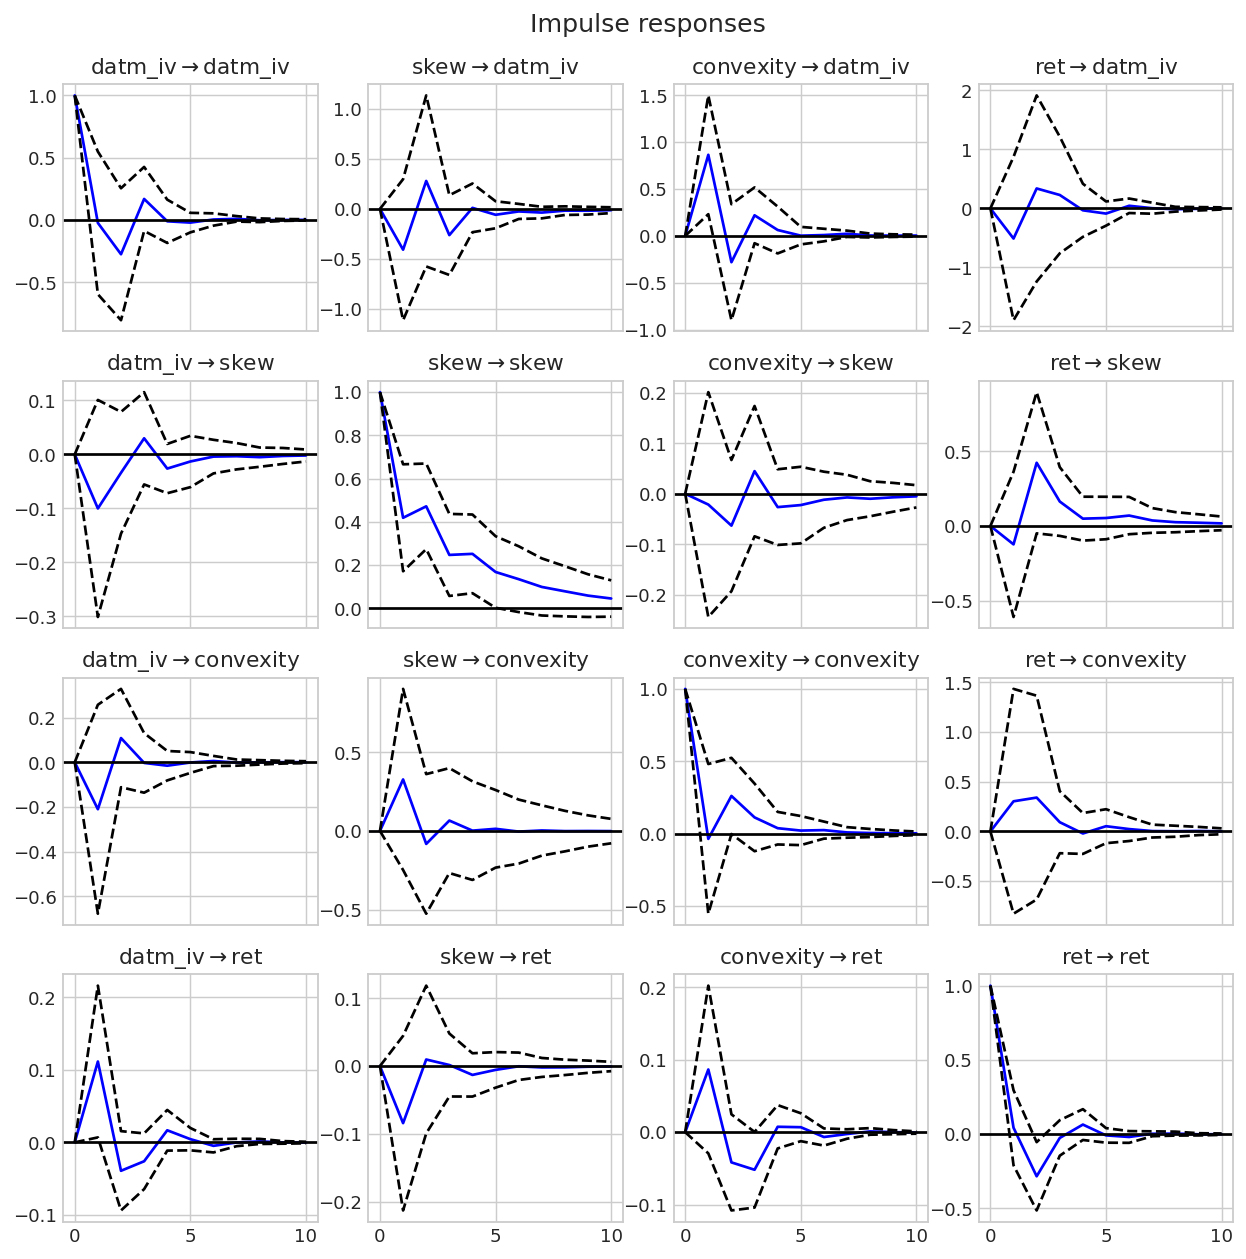

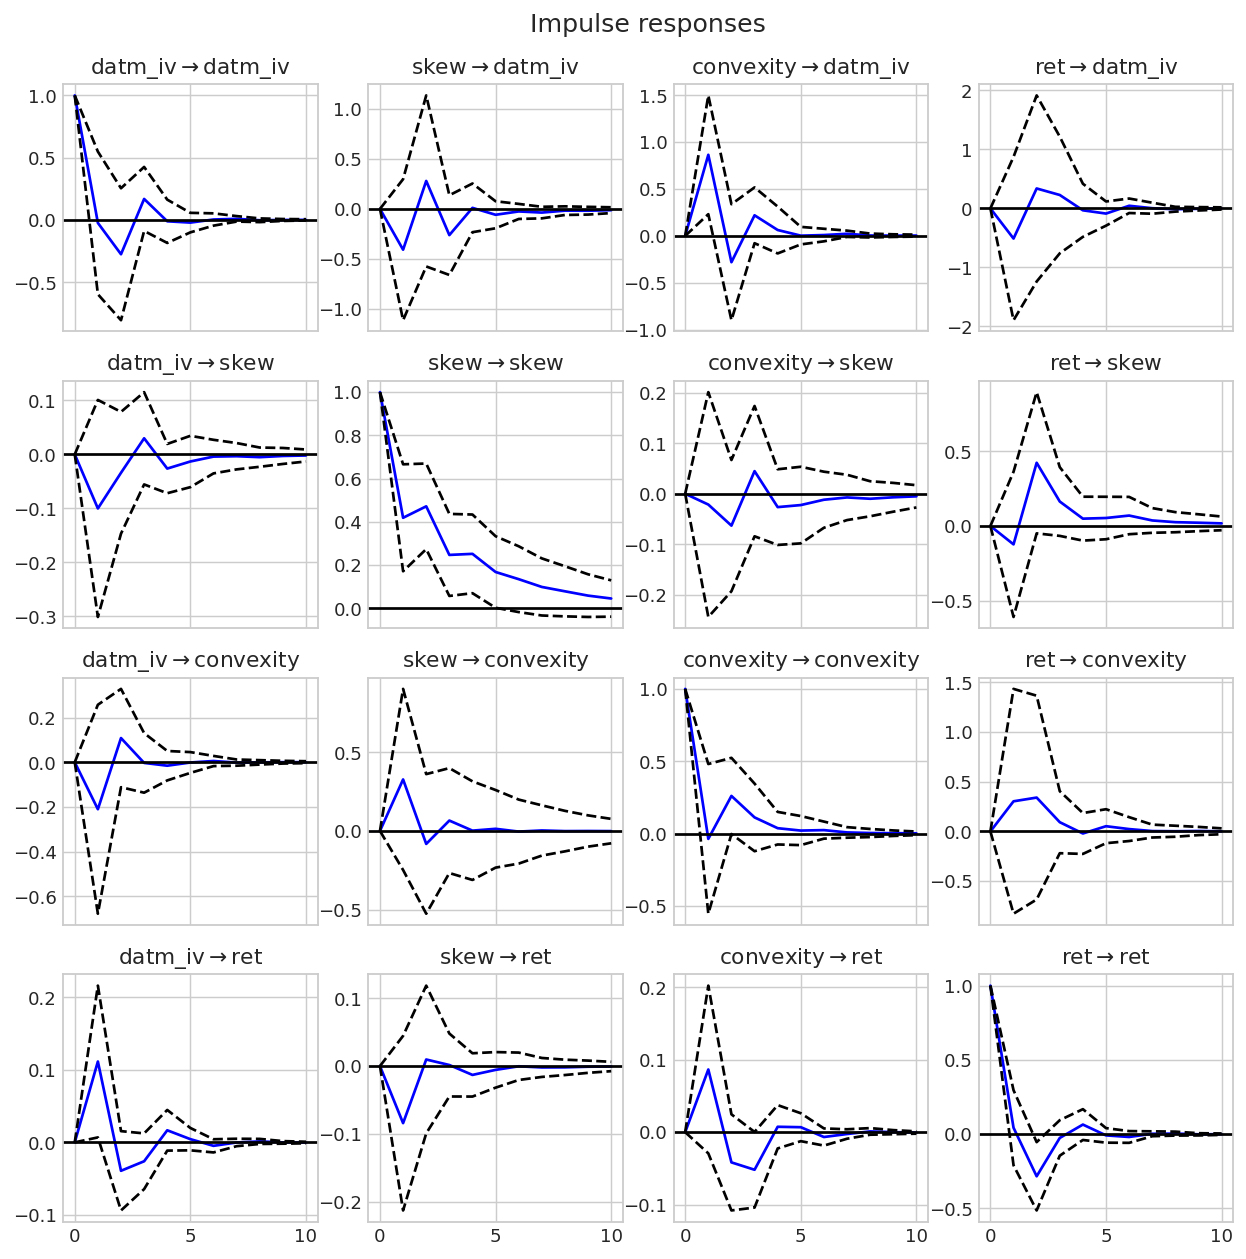

In [45]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)